# ILUSTR 2 — Wyciek widma (spectral leakage): zero-padding vs. okna

DFT po cichu zakłada, że analizowany fragment sygnału jest **jednym pełnym okresem nieskończenie powtarzanego sygnału**. Jeśli w oknie obserwacji mieści się niecałkowita liczba okresów, na złączeniu (koniec okna sklejony z początkiem następnej "kopii") powstaje **nieciągłość** -- a nieciągłość ma bogate widmo, więc energia rozmywa się na sąsiednie biny zamiast skupić w jednym. To zjawisko nazywa się **wyciekiem widma (spectral leakage)**.

Częsty błąd inżynierski: mylenie **zero-paddingu** (dopełnienia zerami) z **oknem (windowing)** -- to dwie zupełnie różne operacje o różnym skutku, mimo że obie "coś robią" z sygnałem przed FFT.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def widmo_amplitudowe(x, fs):
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    amp = np.abs(X) * 2 / N
    amp[0] /= 2
    if N % 2 == 0:
        amp[-1] /= 2
    return freqs, amp

## 1. Całkowita liczba okresów vs. "prawie całkowita" (przykład 10 vs. 10,5 okresu)

Weźmy okno $N=100$ próbek przy $f_s=100$ Hz (czyli $T=1$ s). Sinusoida o częstotliwości dokładnie 10 Hz mieści w oknie **równo 10 pełnych okresów** -- sinusoida o częstotliwości 10,5 Hz mieści **10 i pół** -- na złączeniu jest wyraźny "schodek".

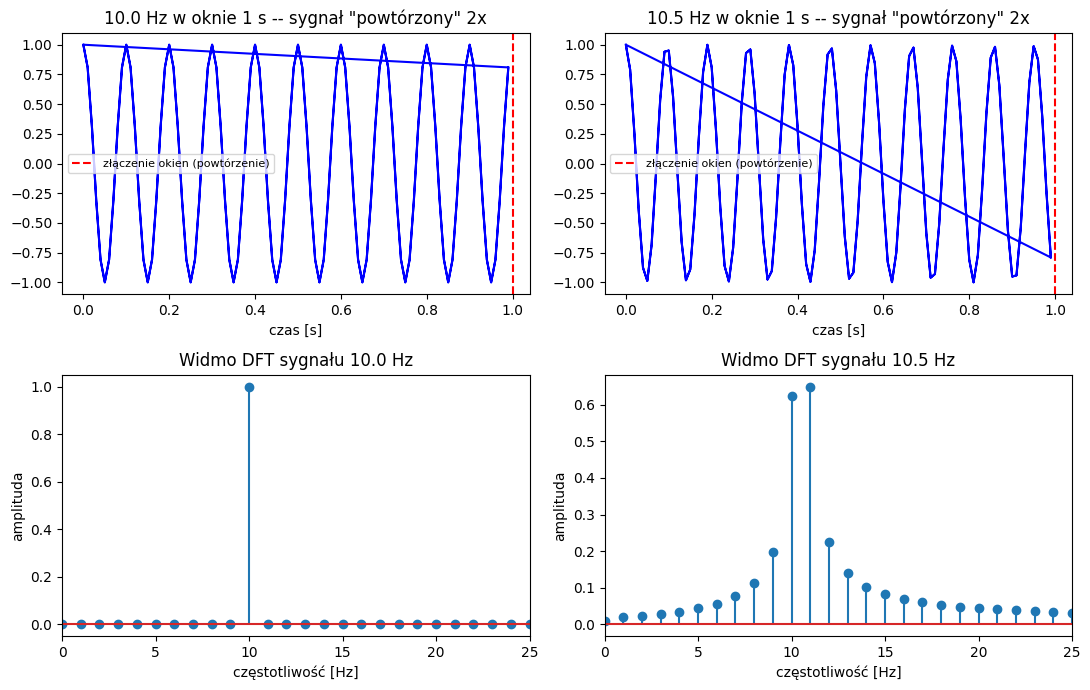

In [2]:
fs = 100.0
N = 100
n = np.arange(N)
t = n / fs

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, f0 in enumerate([10.0, 10.5]):
    sygnal = np.cos(2*np.pi*f0*n/fs)
    freqs, amp = widmo_amplitudowe(sygnal, fs)

    axes[0, col].plot(np.tile(t, 2), np.tile(sygnal, 2), 'b-')
    axes[0, col].axvline(1.0, color='r', linestyle='--', label='złączenie okien (powtórzenie)')
    axes[0, col].set_title(f'{f0} Hz w oknie 1 s -- sygnał "powtórzony" 2x')
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_xlabel('czas [s]')

    axes[1, col].stem(freqs, amp)
    axes[1, col].set_xlim(0, 25)
    axes[1, col].set_xlabel('częstotliwość [Hz]')
    axes[1, col].set_ylabel('amplituda')
    axes[1, col].set_title(f'Widmo DFT sygnału {f0} Hz')

plt.tight_layout()
plt.show()

Dla 10 Hz (lewa kolumna) sygnał "sklejony" ze sobą jest gładki -- widmo to pojedynczy, czysty prążek. Dla 10,5 Hz (prawa kolumna) widać wyraźny skok w miejscu złączenia -- widmo "rozmywa się" na wiele sąsiednich binów zamiast jednego. To właśnie wyciek widma, i wynika **wyłącznie** z tego, że okno nie zawiera całkowitej liczby okresów -- sam sygnał się nie zmienił.

## 2. Zero-padding NIE naprawia wycieku -- tylko go "interpoluje"

Częste błędne przekonanie: "dodam więcej zer, dostanę dokładniejsze widmo". Zero-padding rzeczywiście dodaje więcej punktów w widmie (gęstsza siatka częstotliwości) -- ale to tylko **interpolacja** tego samego rozmycia, nie jego usunięcie. Prawdziwe zmniejszenie wycieku wymaga **okna (windowing)**: przycięcia sygnału na brzegach do zera, żeby złączenie było gładkie.

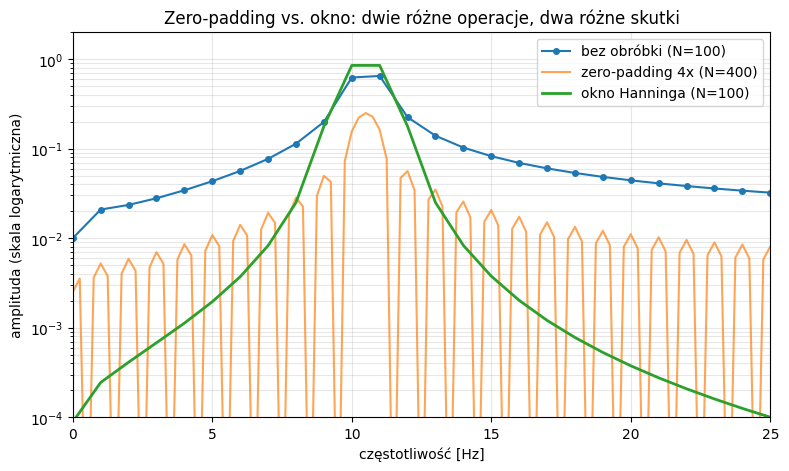

In [3]:
f0 = 10.5
sygnal = np.cos(2*np.pi*f0*n/fs)

# (a) bez żadnej obróbki
freqs_a, amp_a = widmo_amplitudowe(sygnal, fs)

# (b) zero-padding 4x -- ta sama informacja, tylko gęstsza siatka częstotliwości
sygnal_pad = np.concatenate([sygnal, np.zeros(3 * N)])
freqs_b, amp_b = widmo_amplitudowe(sygnal_pad, fs)

# (c) okno Hanninga -- rzeczywiście tłumi wyciek (niższe listki boczne), kosztem szerszego "listka głównego"
okno = np.hanning(N)
sygnal_okno = sygnal * okno
freqs_c, amp_c = widmo_amplitudowe(sygnal_okno, fs)
# Okno zmniejsza sumaryczną energię sygnału (przycina brzegi) -- korekta amplitudy, żeby porównanie było uczciwe.
amp_c = amp_c / np.mean(okno)

plt.figure(figsize=(9, 5))
plt.semilogy(freqs_a, amp_a + 1e-6, 'o-', label='bez obróbki (N=100)', markersize=4)
plt.semilogy(freqs_b, amp_b + 1e-6, '-', label='zero-padding 4x (N=400)', alpha=0.7)
plt.semilogy(freqs_c, amp_c + 1e-6, '-', label='okno Hanninga (N=100)', linewidth=2)
plt.xlim(0, 25)
plt.ylim(1e-4, 2)
plt.xlabel('częstotliwość [Hz]')
plt.ylabel('amplituda (skala logarytmiczna)')
plt.title('Zero-padding vs. okno: dwie różne operacje, dwa różne skutki')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

Zero-padding (pomarańczowa krzywa) rysuje ten sam kształt rozmycia, tylko gęściej spróbkowany -- **żadna nowa informacja się nie pojawiła**, listki boczne mają dokładnie tę samą wysokość co bez paddingu. Okno Hanninga (zielona krzywa) ma wyraźnie **niższe listki boczne** -- to jest rzeczywiste zmniejszenie wycieku, okupione nieco szerszym głównym pikiem (gorsza rozdzielczość dwóch bliskich częstotliwości, patrz poprzedni notebook). To jest właśnie kompromis rozdzielczość-vs-wyciek, o którym mówi się przy doborze okna.

## 3. Galeria okien: kompromis między szerokością listka głównego a tłumieniem listków bocznych

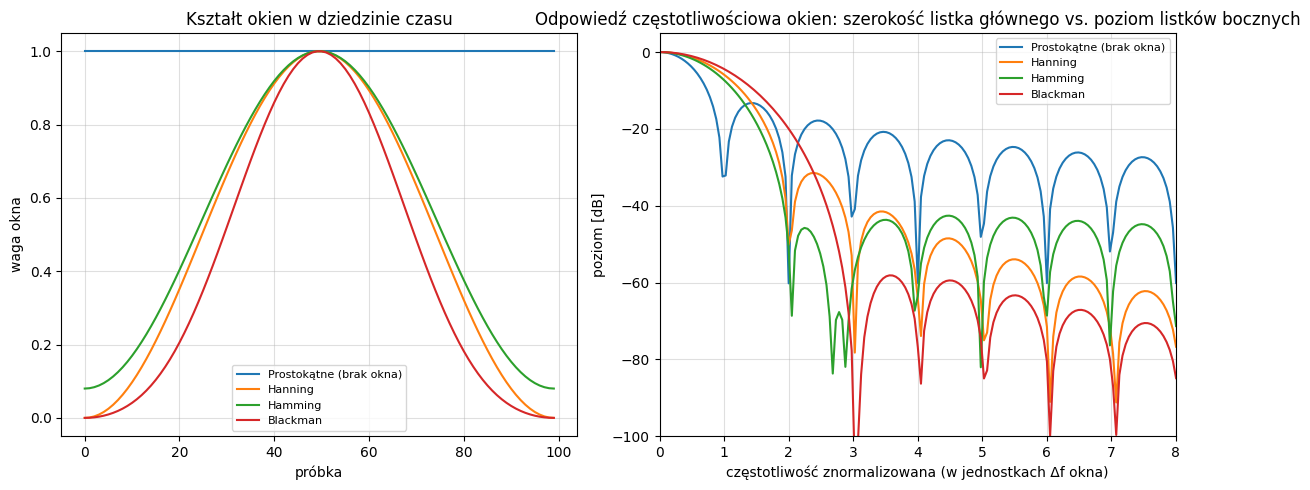

In [4]:
okna = {
    'Prostokątne (brak okna)': np.ones(N),
    'Hanning': np.hanning(N),
    'Hamming': np.hamming(N),
    'Blackman': np.blackman(N),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for nazwa, w in okna.items():
    axes[0].plot(w, label=nazwa)

    # Odpowiedź częstotliwościowa samego okna (nie sygnału!) -- pokazuje kształt "rozmazania" wprowadzanego przez okno.
    W = np.fft.rfft(w, n=2048)
    W_db = 20 * np.log10(np.abs(W) / np.max(np.abs(W)) + 1e-12)
    freqs_w = np.fft.rfftfreq(2048, d=1)
    axes[1].plot(freqs_w * N, W_db, label=nazwa)   # skalowanie osi tak, by 1.0 odpowiadało szerokości okna N

axes[0].set_xlabel('próbka')
axes[0].set_ylabel('waga okna')
axes[0].set_title('Kształt okien w dziedzinie czasu')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].set_xlim(0, 8)
axes[1].set_ylim(-100, 5)
axes[1].set_xlabel('częstotliwość znormalizowana (w jednostkach Δf okna)')
axes[1].set_ylabel('poziom [dB]')
axes[1].set_title('Odpowiedź częstotliwościowa okien: szerokość listka głównego vs. poziom listków bocznych')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Okno prostokątne (czyli brak okna) ma najwęższy listek główny -- najlepszą rozdzielczość -- ale najwyższe listki boczne (najgorsze tłumienie wycieku, spadek tylko ok. 13 dB). Blackman jest na drugim biegunie: szeroki listek główny (gorsza rozdzielczość), ale bardzo niskie listki boczne (silne tłumienie wycieku, ok. 58 dB). Hanning/Hamming leżą pomiędzy. **Nie ma okna uniwersalnie najlepszego** -- wybór zależy od tego, co jest ważniejsze w danym pomiarze: rozdzielczość czy odporność na wyciek z sąsiednich, silniejszych składowych.

## Najważniejsze wnioski

- Wyciek widma bierze się z niecałkowitej liczby okresów w oknie obserwacji -- to nieuniknione dla sygnałów o nieznanej z góry częstotliwości.
- Zero-padding **nie zmniejsza** wycieku -- tylko interpoluje (gęściej próbkuje) to samo rozmycie. Realne narzędzie to okno (windowing), które faktycznie zmienia kształt widma.
- Każde okno to kompromis: węższy listek główny (lepsza rozdzielczość) kosztem wyższych listków bocznych (gorsze tłumienie wycieku), albo odwrotnie -- nie da się poprawić obu naraz przy tej samej długości okna.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.hanning(N)`, `np.hamming(N)`, `np.blackman(N)` | Standardowe funkcje okienkujące długości N |
| `np.concatenate([x, np.zeros(k)])` | Dopełnienie sygnału zerami (zero-padding) |
| `np.fft.rfft(w, n=...)` | DFT z jawnie podaną długością `n` -- tu użyte do gęstego próbkowania odpowiedzi częstotliwościowej samego okna |
| `20*np.log10(...)` | Przeliczenie amplitudy na decybele -- standard przy porównywaniu listków bocznych |

## ĆWICZENIE

1. Zmień częstotliwość sygnału z sekcji 1 na 10,25 Hz i na 10,9 Hz. Jak zmienia się stopień rozmycia widma w zależności od tego, jak blisko pełnej liczby okresów jesteśmy?
2. Zamiast okna Hanninga w sekcji 2 użyj okna Blackmana. Czy listki boczne są jeszcze niższe? Co dzieje się z szerokością głównego piku?
3. **Sygnał z dwiema składowymi o bardzo różnej amplitudzie**: zbuduj `sygnal = cos(2*pi*10*t) + 0.01*cos(2*pi*10.5*t + 3)` (słaba składowa tuż obok silnej). Sprawdź, czy bez okna słaba składowa w ogóle jest widoczna w widmie (może zostać "przykryta" przez listek boczny silnej składowej), a czy z oknem Blackmana staje się widoczna.